<a href="https://colab.research.google.com/github/Akulverma2/AIML-projects/blob/main/Image_Color_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
def get_color_name(rgb):
    r, g, b = rgb

    if r < 50 and g < 50 and b < 50:
        return "Black"
    elif r > 200 and g > 200 and b > 200:
        return "White"
    elif r > g and r > b:
        return "Red-ish"
    elif g > r and g > b:
        return "Green-ish"
    elif b > r and b > g:
        return "Blue-ish"
    else:
        return "Gray"


In [ ]:
# 🔹 Load image
image = cv2.imread("image.jpg")

if image is None:
    print("Error: Image not found. Check file name.")
    exit()

# Convert BGR → RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
# 🔹 Resize (faster processing)
image = cv2.resize(image, (300, 300))
# 🔹 Reshape image to list of pixels
pixels = image.reshape(-1, 3)
# 🔹 Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(pixels)

colors = kmeans.cluster_centers_
labels = kmeans.labels_

In [ ]:
# 🔹 Find most common color
counts = np.bincount(labels)
dominant = colors[counts.argmax()]
# Convert float → int
dominant_color = dominant.astype(int)
# 🔹 Get color name
color_name = get_color_name(dominant_color)
# 🔹 Print results
print("Dominant Color (RGB):", dominant_color)
print("Color Name:", color_name)

Dominant Color (RGB): [21 25 25]
Color Name: Black


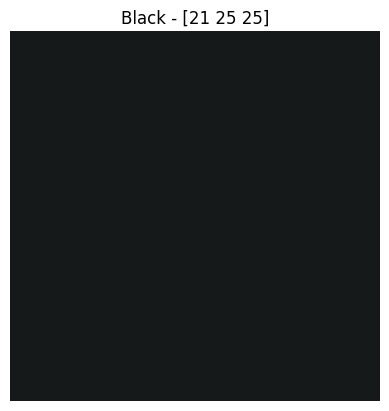

In [ ]:
# 🔹 Show color visually
plt.imshow([[dominant_color]])
plt.title(f"{color_name} - {dominant_color}")
plt.axis('off')
plt.show()